In [1]:
%pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.8/41.9 MB 9.1 MB/s eta 0:00:05
   --- ------------------------------------ 3.1/41.9 MB 8.8 MB/s eta 0:00:05
   ---- ----------------------------------- 5.0/41.9 MB 7.7 MB/s eta 0:00:05
   ----- ---------------------------------- 6.0/41.9 MB 7.2 MB/s eta 0:00:05
   ------ --------------------------------- 6.8/41.9 MB 6.6 MB/s eta 0:00:06
   ------- -------------------------------- 7.3/41.9 MB 5.9 MB/s eta 0:00:06
   ------- -------------------------------- 8.1/41.9 MB 5.5 MB/s eta 0:00:07
   -------- ------------------------------- 9.2/41.9 MB 5.3 MB/s eta 0:00:07
   --------- ------------------------------ 10.0/41.9 MB 5.1 MB/s eta 0:00:07
   ---------- ----------------------------- 11.0/41.9 MB 5.1 MB/s eta 0:00:07
   ---------- ----------------------------- 11.3/41.9 MB 5.0 MB/s eta 0:00:07
   ----------- ---------------------------- 12.1/41.9 MB 4.6 MB/s eta 0:00:07
  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap

print("All libraries imported successfully!")

All libraries imported successfully!


# Task 4: Fairness, Bias and Explainability

## 1. Dataset

The Breast Cancer Wisconsin dataset is used for this analysis. A Logistic Regression model from Task 1 is analyzed using feature importance and SHAP explanations. The analysis also examines potential bias and discusses practical mitigation strategies.

In [3]:
# Load the Breast Cancer Wisconsin dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())
print("\nTarget classes:")
print(data.target_names)

Dataset shape: (569, 30)

Features:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target classes:
['malignant' 'benign']


## 2. Feature Importance

The coefficients of the Logistic Regression model are used to estimate the importance of each feature. The absolute value of each coefficient represents the strength of its contribution to the model.

In [4]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Logistic Regression Accuracy: 0.9824561403508771

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [5]:
# Calculate feature importance from Logistic Regression coefficients

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Absolute Importance": np.abs(model.coef_[0])
})

# Sort by absolute importance
feature_importance = feature_importance.sort_values(
    by="Absolute Importance",
    ascending=False
)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Top 10 Most Important Features:
                 Feature  Coefficient  Absolute Importance
21         worst texture    -1.255088             1.255088
10          radius error    -1.082965             1.082965
27  worst concave points    -0.953686             0.953686
23            worst area    -0.947756             0.947756
20          worst radius    -0.947616             0.947616
28        worst symmetry    -0.939181             0.939181
13            area error    -0.929104             0.929104
26       worst concavity    -0.823151             0.823151
22       worst perimeter    -0.763220             0.763220
24      worst smoothness    -0.746625             0.746625


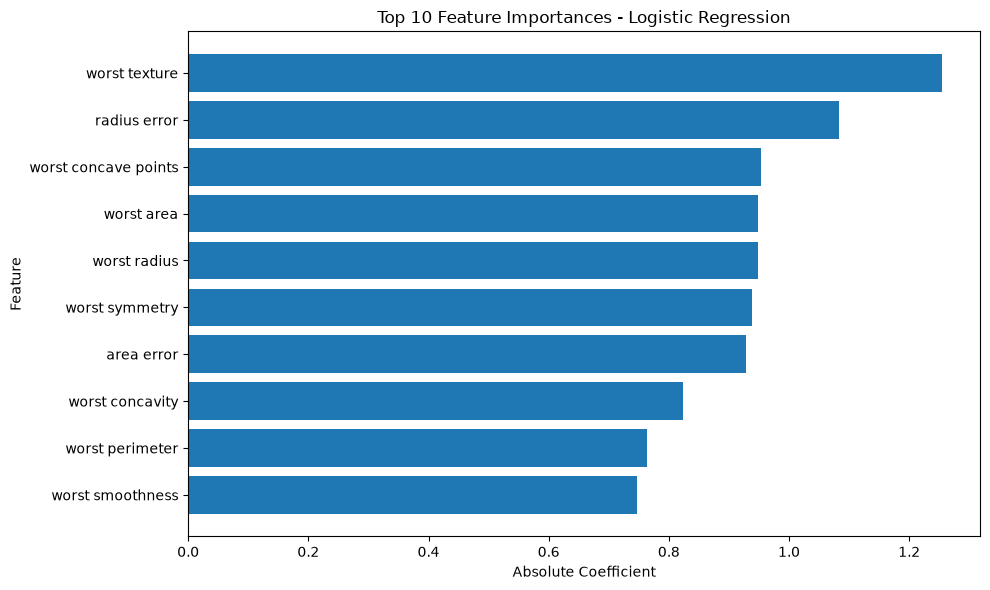

In [6]:
# Plot the top 10 most important features

top_features = feature_importance.head(10).sort_values(
    by="Absolute Importance"
)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Absolute Importance"])
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Logistic Regression")
plt.tight_layout()
plt.show()

## 3. SHAP Global Explanation

SHAP is used to understand how individual features influence the model's predictions across the test dataset. The summary plot provides a global view of feature importance and direction of influence.

In [7]:
# Create SHAP explainer for the Logistic Regression model

explainer = shap.LinearExplainer(model, X_train_scaled)

shap_values = explainer(X_test_scaled)

print("SHAP analysis completed!")

Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


SHAP analysis completed!


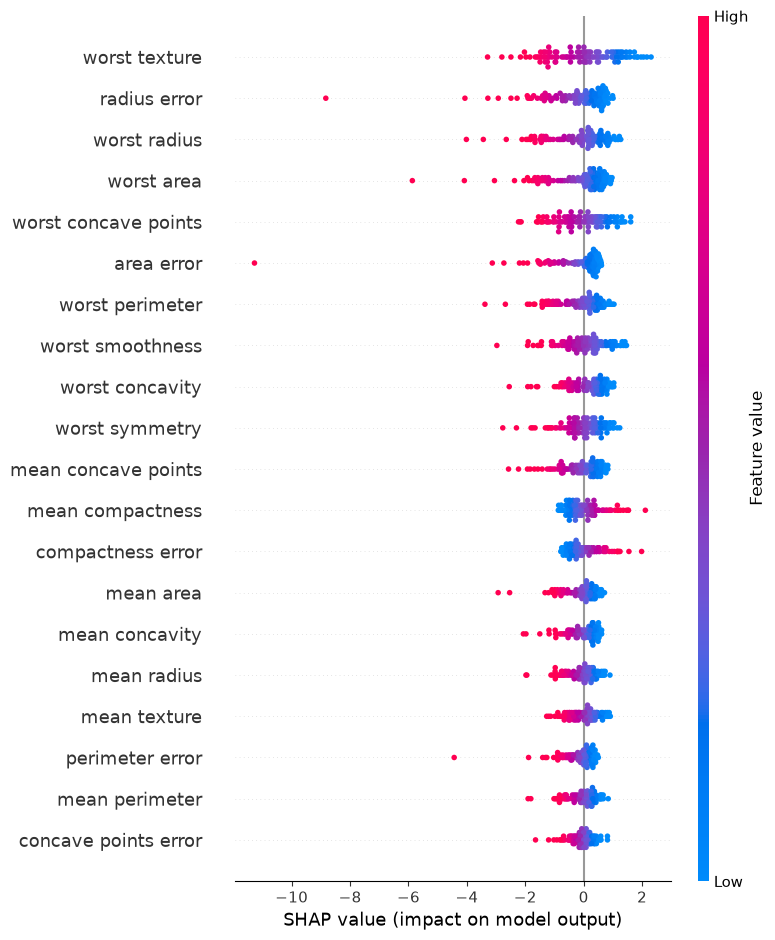

In [8]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

## 5. SHAP Local Explanation

A local SHAP explanation is used to understand how individual features contributed to one specific model prediction. This helps explain why the model classified a particular sample as malignant or benign.

In [9]:
# Select one test sample for local explanation
sample_index = 0

# Display the model's prediction
sample_prediction = model.predict(X_test_scaled[sample_index].reshape(1, -1))[0]

print("Actual class:", data.target_names[y_test.iloc[sample_index]])
print("Predicted class:", data.target_names[sample_prediction])

Actual class: malignant
Predicted class: malignant


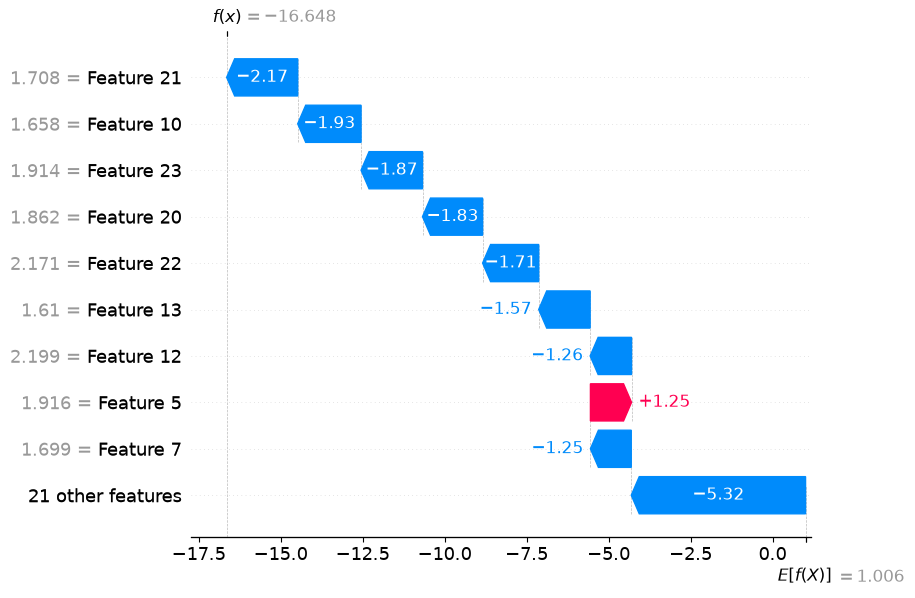

In [10]:
# SHAP waterfall plot for the selected prediction

shap.plots.waterfall(shap_values[sample_index], max_display=10)

## 6. Fairness and Bias Analysis

The dataset does not contain demographic sensitive attributes such as race, ethnicity, income, or education. Therefore, demographic fairness cannot be directly evaluated.

Instead, model performance is compared across the two target classes to identify differences in predictive behavior.

In [11]:
# Fairness / bias analysis
# The dataset does not contain demographic sensitive attributes.
# Therefore, we compare model performance across the two target classes.

from sklearn.metrics import precision_score, recall_score, f1_score

class_results = []

for class_id, class_name in enumerate(data.target_names):
    mask = y_test == class_id
    
    class_accuracy = accuracy_score(
        y_test[mask],
        y_pred[mask]
    )
    
    class_precision = precision_score(
        y_test,
        y_pred,
        labels=[class_id],
        average=None,
        zero_division=0
    )[0]
    
    class_recall = recall_score(
        y_test,
        y_pred,
        labels=[class_id],
        average=None,
        zero_division=0
    )[0]
    
    class_f1 = f1_score(
        y_test,
        y_pred,
        labels=[class_id],
        average=None,
        zero_division=0
    )[0]
    
    class_results.append({
        "Class": class_name,
        "Accuracy": class_accuracy,
        "Precision": class_precision,
        "Recall": class_recall,
        "F1-Score": class_f1
    })

class_results_df = pd.DataFrame(class_results)

print("Performance by Target Class:")
print(class_results_df.round(4))

Performance by Target Class:
       Class  Accuracy  Precision  Recall  F1-Score
0  malignant    0.9762     0.9762  0.9762    0.9762
1     benign    0.9861     0.9861  0.9861    0.9861


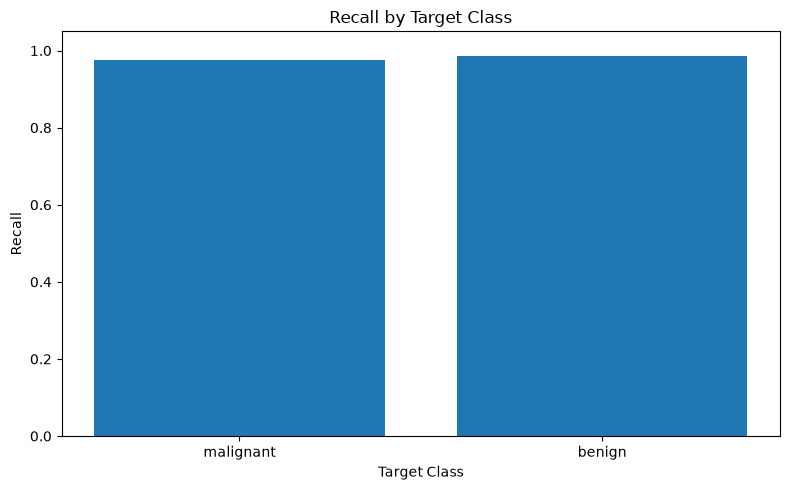

In [12]:
# Plot recall by target class

plt.figure(figsize=(8, 5))

plt.bar(
    class_results_df["Class"],
    class_results_df["Recall"]
)

plt.ylim(0, 1.05)
plt.xlabel("Target Class")
plt.ylabel("Recall")
plt.title("Recall by Target Class")
plt.tight_layout()
plt.show()

## Bias Mitigation Recommendations

The Breast Cancer Wisconsin dataset does not contain demographic sensitive attributes such as race, ethnicity, income, or education. Therefore, demographic fairness cannot be directly measured using this dataset.

However, the following practical mitigation strategies can be applied when sensitive-group information is available:

1. **Use representative training data:** Ensure that the training dataset contains sufficient representation of all relevant demographic groups.

2. **Evaluate subgroup performance:** Compare accuracy, precision, recall, F1-score, and false-positive/false-negative rates across sensitive groups.

3. **Apply re-sampling or re-weighting:** If certain groups are underrepresented, increase their representation through appropriate sampling or assign higher training weights.

4. **Adjust the decision threshold:** If the model produces substantially different error rates across groups, threshold optimization can be considered where appropriate.

5. **Monitor the model after deployment:** Fairness should be checked periodically because model performance can change when the input population changes.

6. **Collect relevant demographic information responsibly:** Future versions of the dataset could include appropriate sensitive attributes, with privacy protection and ethical safeguards, to enable meaningful fairness evaluation.

7. **Use explainability tools:** SHAP explanations can help identify which features strongly influence predictions and can support investigation of unexpected model behavior.

## Conclusion

The Logistic Regression model achieved high predictive performance on the Breast Cancer Wisconsin dataset, with an accuracy of approximately 98.25%.

Feature importance analysis identified the features with the strongest influence on the model. SHAP was then used to provide both global and local explanations of the model's predictions. The global SHAP analysis showed which features generally had the greatest impact, while the local waterfall plot demonstrated how individual feature values contributed to a specific prediction.

A fairness analysis was also performed by comparing model performance across the two target classes. However, the dataset does not contain demographic sensitive attributes, so formal demographic fairness analysis could not be performed.

For future applications, fairness should be evaluated using appropriate demographic or sensitive-group information, provided that such data can be collected and handled responsibly. Recommended mitigation strategies include representative sampling, re-weighting, subgroup performance monitoring, threshold analysis, and continuous evaluation after deployment.

Overall, the analysis demonstrates that model performance alone is not sufficient. Understanding model decisions, identifying potential sources of bias, and monitoring fairness are important components of responsible machine learning.